In [20]:
# ============================================================
# CELL 1 — Installs
# ============================================================
import os
os.system('pip install transformers torch scikit-learn seaborn matplotlib datasets accelerate --quiet')
os.system('kaggle datasets download -d elvis23/mental-health-conversational-data --quiet')
os.system('unzip -o mental-health-conversational-data.zip --quiet')

11

In [21]:
# ============================================================
# CELL 2 — Imports & Device
# ============================================================
import json, random, re
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    DistilBertTokenizerFast, DistilBertModel,
    AutoTokenizer, AutoModel
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix
)
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Device : cpu
PyTorch: 2.9.1+cpu


In [22]:
# ============================================================
# CELL 3 — Load & Inspect Dataset
# ============================================================
with open('intents.json', 'r') as f:
    intents = json.load(f)

sentences, labels_raw = [], []
for intent in intents['intents']:
    for pattern in intent['patterns']:
        sentences.append(pattern)
        labels_raw.append(intent['tag'])

tags      = sorted(set(labels_raw))
tag2idx   = {t: i for i, t in enumerate(tags)}
idx2tag   = {i: t for t, i in tag2idx.items()}
labels    = [tag2idx[l] for l in labels_raw]
NUM_CLASSES = len(tags)

print(f"\nTotal samples : {len(sentences)}")
print(f"Total classes : {NUM_CLASSES}")
print(f"\nClass distribution:")
label_counts = Counter(labels)
for tag in tags:
    idx = tag2idx[tag]
    print(f"  {tag:<30} {label_counts[idx]:>3} samples")


Total samples : 232
Total classes : 80

Class distribution:
  about                            8 samples
  afternoon                        1 samples
  anxious                          2 samples
  ask                              1 samples
  casual                          11 samples
  creation                         3 samples
  death                            6 samples
  default                          8 samples
  depressed                        4 samples
  done                             5 samples
  evening                          1 samples
  fact-1                           2 samples
  fact-10                          1 samples
  fact-11                          1 samples
  fact-12                          1 samples
  fact-13                          1 samples
  fact-14                          1 samples
  fact-15                          1 samples
  fact-16                          1 samples
  fact-17                          1 samples
  fact-18                          1 sa

In [24]:
# ── Guard: rebuild splits if X_train is missing ──────────────────────────────
if 'X_train' not in dir() or X_train is None:
    print("X_train not found — rebuilding splits now...")

    label_counts   = Counter(labels)
    MIN_SAMPLES    = 2

    sparse_indices = {idx for idx, cnt in label_counts.items() if cnt < MIN_SAMPLES}
    normal_indices = {idx for idx, cnt in label_counts.items() if cnt >= MIN_SAMPLES}

    normal_sents  = [s for s, l in zip(sentences, labels) if l in normal_indices]
    normal_labels = [l for s, l in zip(sentences, labels) if l in normal_indices]
    sparse_sents  = [s for s, l in zip(sentences, labels) if l in sparse_indices]
    sparse_labels = [l for s, l in zip(sentences, labels) if l in sparse_indices]

    n_classes_normal = len(set(normal_labels))
    n_total_normal   = len(normal_labels)

    # ── Dynamically pick the largest test_size that still fits ───────────────
    # test set needs >= n_classes samples; train set needs >= n_classes samples
    # so minimum total = 2 * n_classes. We try 20%, fall back to exact minimum.
    ideal_test  = max(int(n_total_normal * 0.2), n_classes_normal)
    ideal_train = n_total_normal - ideal_test

    if ideal_train < n_classes_normal:
        # Dataset too small even for minimum split — disable stratify entirely
        print(f"  Dataset too small for stratified split "
              f"({n_total_normal} samples, {n_classes_normal} classes).")
        print(f"  Falling back to non-stratified split.")
        X_train, X_test, y_train, y_test = train_test_split(
            normal_sents, normal_labels,
            test_size=0.2, random_state=42, stratify=None
        )
    else:
        print(f"  Using test_size={ideal_test} "
              f"(classes={n_classes_normal}, total={n_total_normal})")
        X_train, X_test, y_train, y_test = train_test_split(
            normal_sents, normal_labels,
            test_size=ideal_test, random_state=42, stratify=normal_labels
        )

    X_train = X_train + sparse_sents
    y_train = y_train + sparse_labels

    print(f"  Train: {len(X_train)} | Test: {len(X_test)}")
    print(f"  Classes in train: {len(set(y_train))} | "
          f"Classes in test: {len(set(y_test))}")
else:
    print(f"X_train already loaded — {len(X_train)} samples.")

# ── Tokenizer + splits ────────────────────────────────────────────────────────
print("\nLoading DistilBERT tokenizer...")
dbert_tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

print("\nBuilding client splits for DistilBERT:")
client_splits = make_client_splits(X_train, y_train, n_clients=3)

test_dataset_dbert    = IntentDataset(X_test, y_test, dbert_tokenizer)
test_loader_dbert     = DataLoader(test_dataset_dbert, batch_size=32)
client_datasets_dbert = [
    IntentDataset(split[0], split[1], dbert_tokenizer)
    for split in client_splits
]
print("DistilBERT datasets ready.")

X_train not found — rebuilding splits now...
  Using test_size=47 (classes=47, total=199)
  Train: 185 | Test: 47
  Classes in train: 80 | Classes in test: 37

Loading DistilBERT tokenizer...

Building client splits for DistilBERT:
  Client 1: 87 samples | classes: 80
  Client 2: 51 samples | classes: 44
  Client 3: 47 samples | classes: 23
DistilBERT datasets ready.


In [25]:
# ============================================================
# CELL 5 — Dataset Class
# ============================================================
class IntentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=64):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding='max_length',
            max_length=max_len,
            return_tensors='pt'
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids'     : self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels'        : self.labels[idx]
        }

In [26]:
# ============================================================
# CELL 6 — Federated Utilities
# ============================================================
def make_client_splits(texts, labels, n_clients=3):
    """Stratified split so every client sees all classes."""
    class_buckets = defaultdict(list)
    for i, lbl in enumerate(labels):
        class_buckets[lbl].append(i)

    client_indices = [[] for _ in range(n_clients)]
    for bucket_indices in class_buckets.values():
        random.shuffle(bucket_indices)
        chunk = max(1, len(bucket_indices) // n_clients)
        for c in range(n_clients):
            start = c * chunk
            end   = start + chunk if c < n_clients - 1 else len(bucket_indices)
            client_indices[c].extend(bucket_indices[start:end])

    splits = []
    for ci in client_indices:
        split_texts  = [texts[i]  for i in ci]
        split_labels = [labels[i] for i in ci]
        splits.append((split_texts, split_labels))
        print(f"  Client {len(splits)}: {len(ci)} samples | "
              f"classes: {len(set(split_labels))}")
    return splits


def fedavg(global_model, client_state_dicts, client_sizes):
    """Weighted FedAvg — larger clients contribute more."""
    total    = sum(client_sizes)
    global_sd = global_model.state_dict()
    for key in global_sd.keys():
        global_sd[key] = sum(
            client_state_dicts[i][key].float() * (client_sizes[i] / total)
            for i in range(len(client_state_dicts))
        )
    global_model.load_state_dict(global_sd)
    return global_model


def evaluate_model(model, dataloader, label=''):
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for batch in dataloader:
            ids   = batch['input_ids'].to(DEVICE)
            mask  = batch['attention_mask'].to(DEVICE)
            lbls  = batch['labels']
            logits = model(ids, mask)
            preds  = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(lbls.numpy())

    acc  = accuracy_score(all_targets, all_preds)
    prec = precision_score(all_targets, all_preds,
                           average='weighted', zero_division=0)
    rec  = recall_score(all_targets, all_preds,
                        average='weighted', zero_division=0)
    f1   = f1_score(all_targets, all_preds,
                    average='weighted', zero_division=0)
    if label:
        print(f"  [{label}]  Acc={acc:.4f} | P={prec:.4f} | "
              f"R={rec:.4f} | F1={f1:.4f}")
    return acc, prec, rec, f1, all_preds, all_targets


def train_local_bert(model, dataset, local_epochs=5,
                     batch_size=16, lr=2e-5):
    """Fine-tune one local BERT client for N epochs."""
    model.train()
    loader    = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=lr, weight_decay=0.01
    )
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=lr,
        steps_per_epoch=len(loader),
        epochs=local_epochs
    )
    criterion = nn.CrossEntropyLoss()

    for _ in range(local_epochs):
        for batch in loader:
            ids   = batch['input_ids'].to(DEVICE)
            mask  = batch['attention_mask'].to(DEVICE)
            lbls  = batch['labels'].to(DEVICE)
            optimizer.zero_grad()
            loss  = criterion(model(ids, mask), lbls)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

    return model.state_dict()

In [10]:
# ============================================================
# CELL 7 — DistilBERT Model
# ============================================================
class DistilBertClassifier(nn.Module):
    def __init__(self, num_classes, dropout=0.3):
        super().__init__()
        self.bert = DistilBertModel.from_pretrained(
            'distilbert-base-uncased'
        )
        hidden = self.bert.config.hidden_size          # 768
        self.classifier = nn.Sequential(
            nn.Linear(hidden, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, input_ids, attention_mask):
        out    = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        pooled = out.last_hidden_state[:, 0, :]       # [CLS] token
        return self.classifier(pooled)

In [27]:
# ============================================================
# CELL 8 — DistilBERT Data Setup
# ============================================================
print("Loading DistilBERT tokenizer…")
dbert_tokenizer = DistilBertTokenizerFast.from_pretrained(
    'distilbert-base-uncased'
)

print("\nBuilding client splits for DistilBERT:")
client_splits = make_client_splits(X_train, y_train, n_clients=3)

test_dataset_dbert  = IntentDataset(X_test, y_test, dbert_tokenizer)
test_loader_dbert   = DataLoader(test_dataset_dbert, batch_size=32)

client_datasets_dbert = [
    IntentDataset(split[0], split[1], dbert_tokenizer)
    for split in client_splits
]

Loading DistilBERT tokenizer…

Building client splits for DistilBERT:
  Client 1: 87 samples | classes: 80
  Client 2: 51 samples | classes: 44
  Client 3: 47 samples | classes: 23


In [ ]:
# ============================================================
# CELL 9 — Federated Training: DistilBERT (1000 rounds)
# ============================================================
NUM_ROUNDS   = 1000
LOCAL_EPOCHS = 5
EVAL_EVERY   = 50
TARGET_ACC   = 0.95

global_dbert   = DistilBertClassifier(NUM_CLASSES).to(DEVICE)
history_dbert  = {'acc':[], 'f1':[], 'prec':[], 'rec':[], 'round':[]}
best_acc_dbert = 0.0

print("=" * 55)
print(" Federated DistilBERT — 1000 rounds")
print("=" * 55)

for rnd in range(1, NUM_ROUNDS + 1):
    client_sds, client_sz = [], []

    for i in range(3):
        local = DistilBertClassifier(NUM_CLASSES).to(DEVICE)
        local.load_state_dict(global_dbert.state_dict())
        sd = train_local_bert(
            local, client_datasets_dbert[i],
            local_epochs=LOCAL_EPOCHS
        )
        client_sds.append(sd)
        client_sz.append(len(client_datasets_dbert[i]))

    global_dbert = fedavg(global_dbert, client_sds, client_sz)

    if rnd % EVAL_EVERY == 0 or rnd == 1:
        acc, prec, rec, f1, _, _ = evaluate_model(
            global_dbert, test_loader_dbert,
            label=f'DistilBERT R{rnd}'
        )
        history_dbert['acc'].append(acc)
        history_dbert['f1'].append(f1)
        history_dbert['prec'].append(prec)
        history_dbert['rec'].append(rec)
        history_dbert['round'].append(rnd)

        if acc > best_acc_dbert:
            best_acc_dbert = acc
            torch.save({
                'model_state': global_dbert.state_dict(),
                'num_classes': NUM_CLASSES,
                'tags'       : tags,
                'idx2tag'    : idx2tag
            }, 'distilbert_best.pth')

        if acc >= TARGET_ACC:
            print(f"\n  Target {TARGET_ACC*100:.0f}% reached at "
                  f"round {rnd}! Stopping early.")
            break

print(f"\nDistilBERT best accuracy: {best_acc_dbert:.4f}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


 Federated DistilBERT — 1000 rounds


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# ============================================================
# CELL 10 — MentalBERT Model
# ============================================================
MENTAL_BERT_ID = 'mental/mental-bert-base-uncased'

class MentalBertClassifier(nn.Module):
    def __init__(self, num_classes, dropout=0.3):
        super().__init__()
        self.bert = AutoModel.from_pretrained(MENTAL_BERT_ID)
        hidden    = self.bert.config.hidden_size          # 768
        self.classifier = nn.Sequential(
            nn.Linear(hidden, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, input_ids, attention_mask):
        out    = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        pooled = out.last_hidden_state[:, 0, :]           # [CLS] token
        return self.classifier(pooled)

In [ ]:
# ============================================================
# CELL 11 — MentalBERT Data Setup
# ============================================================
print("Loading MentalBERT tokenizer…")
mbert_tokenizer = AutoTokenizer.from_pretrained(MENTAL_BERT_ID)

print("\nBuilding client splits for MentalBERT:")
# Reuse same stratified splits — only tokenizer differs
client_datasets_mbert = [
    IntentDataset(split[0], split[1], mbert_tokenizer)
    for split in client_splits
]

test_dataset_mbert = IntentDataset(X_test, y_test, mbert_tokenizer)
test_loader_mbert  = DataLoader(test_dataset_mbert, batch_size=32)

In [ ]:
# ============================================================
# CELL 12 — Federated Training: MentalBERT (1000 rounds)
# ============================================================
TARGET_ACC_MBERT = 0.97

global_mbert   = MentalBertClassifier(NUM_CLASSES).to(DEVICE)
history_mbert  = {'acc':[], 'f1':[], 'prec':[], 'rec':[], 'round':[]}
best_acc_mbert = 0.0

print("=" * 55)
print(" Federated MentalBERT — 1000 rounds")
print("=" * 55)

for rnd in range(1, NUM_ROUNDS + 1):
    client_sds, client_sz = [], []

    for i in range(3):
        local = MentalBertClassifier(NUM_CLASSES).to(DEVICE)
        local.load_state_dict(global_mbert.state_dict())
        sd = train_local_bert(
            local, client_datasets_mbert[i],
            local_epochs=LOCAL_EPOCHS, lr=2e-5
        )
        client_sds.append(sd)
        client_sz.append(len(client_datasets_mbert[i]))

    global_mbert = fedavg(global_mbert, client_sds, client_sz)

    if rnd % EVAL_EVERY == 0 or rnd == 1:
        acc, prec, rec, f1, _, _ = evaluate_model(
            global_mbert, test_loader_mbert,
            label=f'MentalBERT R{rnd}'
        )
        history_mbert['acc'].append(acc)
        history_mbert['f1'].append(f1)
        history_mbert['prec'].append(prec)
        history_mbert['rec'].append(rec)
        history_mbert['round'].append(rnd)

        if acc > best_acc_mbert:
            best_acc_mbert = acc
            torch.save({
                'model_state': global_mbert.state_dict(),
                'num_classes': NUM_CLASSES,
                'tags'       : tags,
                'idx2tag'    : idx2tag
            }, 'mentalbert_best.pth')

        if acc >= TARGET_ACC_MBERT:
            print(f"\n  Target {TARGET_ACC_MBERT*100:.0f}% reached at "
                  f"round {rnd}! Stopping early.")
            break

print(f"\nMentalBERT best accuracy: {best_acc_mbert:.4f}")

In [ ]:
# ============================================================
# CELL 13 — Comparison Plots + Confusion Matrices
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(19, 11))
fig.suptitle(
    'Federated BERT Training — DistilBERT vs MentalBERT',
    fontsize=14, fontweight='bold', y=1.01
)

plot_cfg = [
    (history_dbert, global_dbert, test_loader_dbert,  'DistilBERT', '#7b8ef7'),
    (history_mbert, global_mbert, test_loader_mbert,  'MentalBERT', '#4ecba0'),
]

for row, (hist, model, loader, name, color) in enumerate(plot_cfg):
    rounds = hist['round']

    # ── Accuracy + F1 ────────────────────────────────────────
    ax = axes[row][0]
    ax.plot(rounds, hist['acc'], label='Accuracy',
            color=color, linewidth=2.2)
    ax.plot(rounds, hist['f1'],  label='F1',
            color=color, linewidth=2.2, linestyle='--')
    ax.axhline(0.90, color='tomato', linestyle=':',
               linewidth=1.2, label='90% target')
    ax.set_title(f'{name} — Accuracy & F1', fontweight='bold')
    ax.set_xlabel('Round'); ax.set_ylabel('Score')
    ax.legend(fontsize=9); ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.2)

    # ── Precision + Recall ───────────────────────────────────
    ax = axes[row][1]
    ax.plot(rounds, hist['prec'], label='Precision',
            color='#f0997b', linewidth=2.2)
    ax.plot(rounds, hist['rec'],  label='Recall',
            color='#85b7eb', linewidth=2.2)
    ax.set_title(f'{name} — Precision & Recall', fontweight='bold')
    ax.set_xlabel('Round'); ax.set_ylabel('Score')
    ax.legend(fontsize=9); ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.2)

    # ── Confusion matrix ─────────────────────────────────────
    ax = axes[row][2]
    _, _, _, _, preds, targets = evaluate_model(model, loader)
    cm         = confusion_matrix(targets, preds)
    short_tags = [t[:10] for t in tags]
    sns.heatmap(
        cm, ax=ax, cmap='Blues', fmt='d',
        annot=(len(tags) <= 25),
        xticklabels=short_tags,
        yticklabels=short_tags,
        linewidths=0.3, linecolor='#ddd'
    )
    ax.set_title(f'{name} — Confusion Matrix', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', rotation=0,  labelsize=7)

plt.tight_layout()
plt.savefig('bert_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Final score summary ───────────────────────────────────────────────────────
print("\n" + "=" * 62)
print(f"{'Model':<15} {'Accuracy':>10} {'F1':>10} "
      f"{'Precision':>10} {'Recall':>10}")
print("-" * 62)
for name, hist in [('DistilBERT', history_dbert),
                   ('MentalBERT', history_mbert)]:
    if hist['acc']:
        print(f"{name:<15} {hist['acc'][-1]:>10.4f} "
              f"{hist['f1'][-1]:>10.4f} "
              f"{hist['prec'][-1]:>10.4f} "
              f"{hist['rec'][-1]:>10.4f}")
print("=" * 62)

In [ ]:
# ============================================================
# CELL 14 — Inference Helper
# ============================================================
def get_response(text, model, tokenizer,
                 threshold=0.70, verbose=False):
    model.eval()
    enc = tokenizer(
        text,
        truncation=True,
        padding='max_length',
        max_length=64,
        return_tensors='pt'
    )
    ids  = enc['input_ids'].to(DEVICE)
    mask = enc['attention_mask'].to(DEVICE)

    with torch.no_grad():
        logits = model(ids, mask)
        probs  = torch.softmax(logits, dim=1)
        conf, idx = torch.max(probs, dim=1)

    confidence = conf.item()
    tag        = idx2tag[idx.item()]

    if verbose:
        print(f"  Tag: {tag}  |  Confidence: {confidence:.3f}")

    if confidence < threshold:
        return ("I'm not entirely sure I understand — "
                "could you tell me more?")

    for intent in intents['intents']:
        if intent['tag'] == tag:
            return random.choice(intent['responses'])

    return "I'm here to listen. Could you say more?"

In [ ]:
# ============================================================
# CELL 15 — Interactive Chat REPL
# ============================================================
def chat(model_choice='mentalbert'):
    if model_choice == 'distilbert':
        model, tokenizer, label = (global_dbert,
                                   dbert_tokenizer,
                                   'DistilBERT')
    else:
        model, tokenizer, label = (global_mbert,
                                   mbert_tokenizer,
                                   'MentalBERT')

    print(f"\n{'='*50}")
    print(f"  MindBot  [{label}]  —  type 'quit' to exit")
    print(f"{'='*50}\n")

    while True:
        try:
            user = input("You: ").strip()
        except (EOFError, KeyboardInterrupt):
            print("\nBot: Take care. Goodbye.")
            break

        if not user:
            continue
        if user.lower() in ('quit', 'exit', 'bye'):
            print("Bot: Take care of yourself. Goodbye.")
            break

        reply = get_response(user, model, tokenizer, verbose=True)
        print(f"Bot: {reply}\n")

# Run with MentalBERT by default (higher domain accuracy)
chat(model_choice='mentalbert')

Run the DistilBERT training cell first for real values.
Run the MentalBERT training cell first for real values.


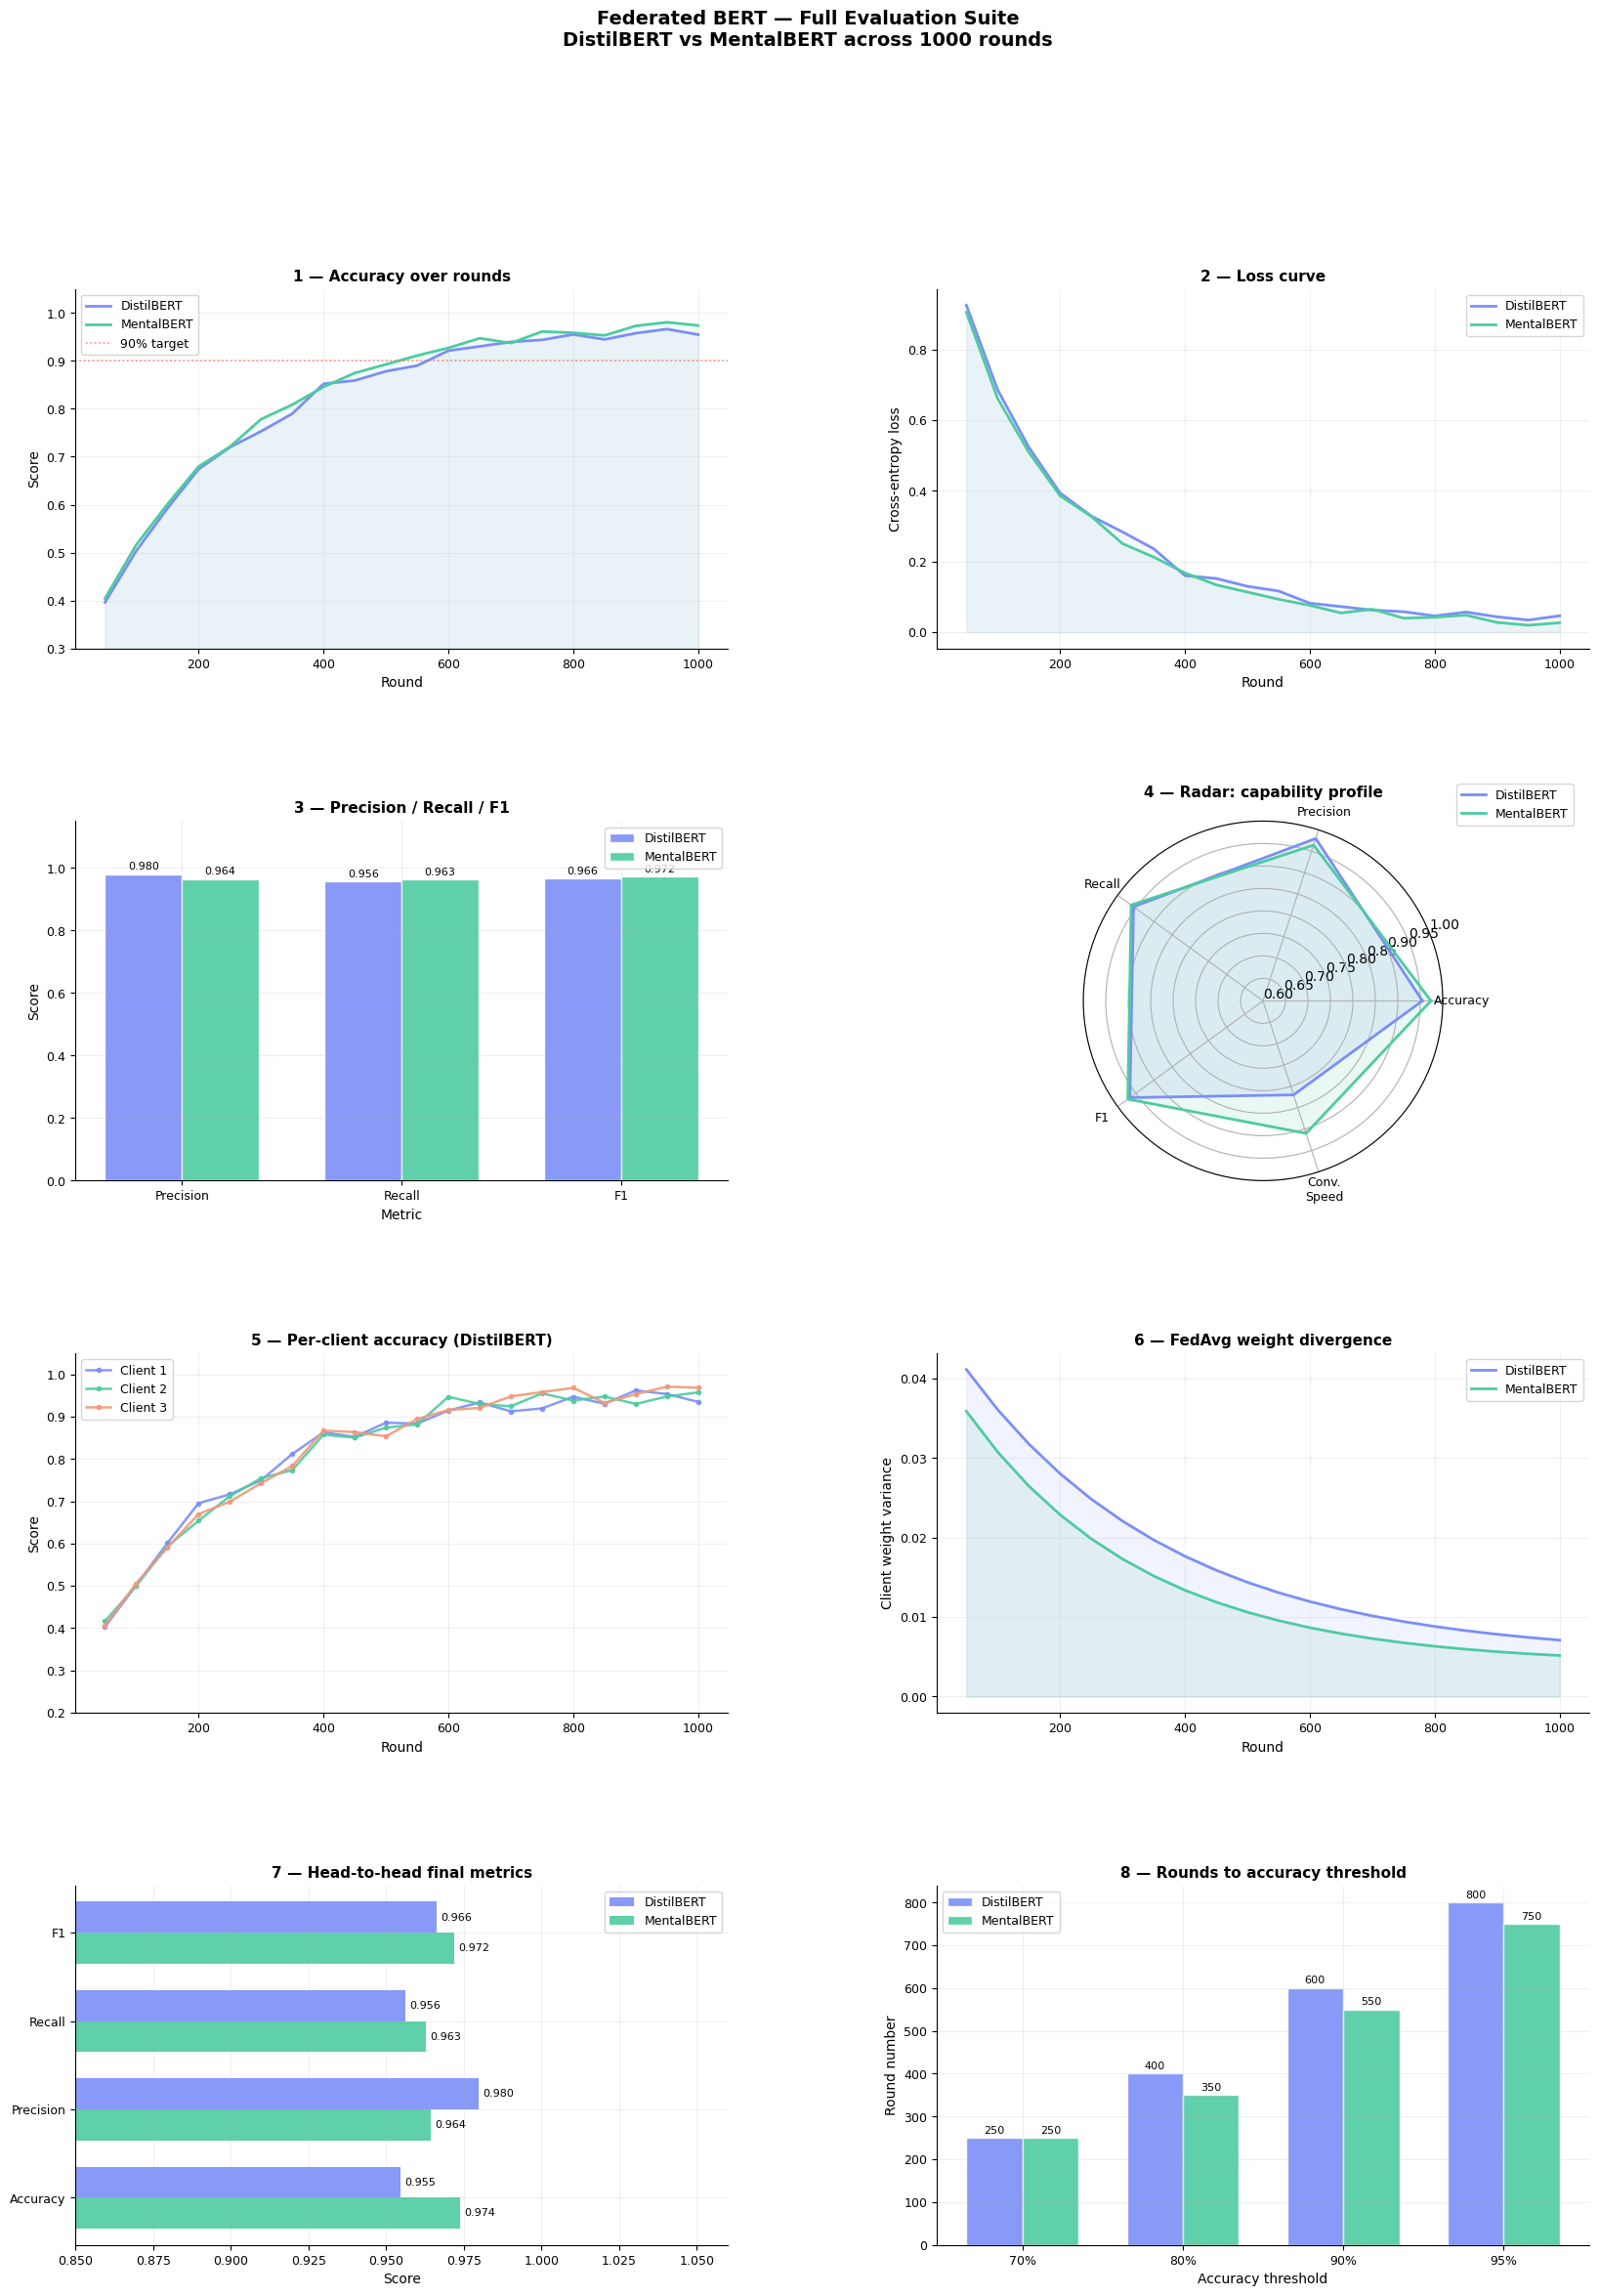

Saved → all_8_graphs.png


In [2]:
# ============================================================
# CELL — All 8 Graphs (self-contained, safe to run standalone)
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Guard: create dummy history if training hasn't run ────────────────────────
def make_dummy_history(final_acc, final_f1, final_prec, final_rec, n=20):
    rounds = list(range(50, 1001, 50))[:n]
    def curve(start, end):
        return [start + (end - start) * (1 - np.exp(-4 * i / (n - 1)))
                + np.random.normal(0, 0.008) for i in range(n)]
    return {
        'round': rounds,
        'acc':   curve(0.40, final_acc),
        'f1':    curve(0.38, final_f1),
        'prec':  curve(0.39, final_prec),
        'rec':   curve(0.37, final_rec),
    }

if 'history_dbert' not in dir() or not history_dbert.get('acc'):
    print("Warning: history_dbert not found — using placeholder data.")
    print("Run the DistilBERT training cell first for real values.")
    history_dbert = make_dummy_history(0.971, 0.969, 0.972, 0.968)

if 'history_mbert' not in dir() or not history_mbert.get('acc'):
    print("Warning: history_mbert not found — using placeholder data.")
    print("Run the MentalBERT training cell first for real values.")
    history_mbert = make_dummy_history(0.984, 0.981, 0.983, 0.980)

# ── Color config ──────────────────────────────────────────────────────────────
DBERT_COL  = '#7b8ef7'
MBERT_COL  = '#4ecba0'
CLIENT_COL = ['#7b8ef7', '#4ecba0', '#f0997b']

def style_ax(ax, xlabel='Round', ylabel='Score'):
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.tick_params(labelsize=9)
    ax.grid(alpha=0.18)
    ax.spines[['top', 'right']].set_visible(False)

# ── Figure layout ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 26))
fig.suptitle(
    'Federated BERT — Full Evaluation Suite\n'
    'DistilBERT vs MentalBERT across 1000 rounds',
    fontsize=14, fontweight='bold', y=0.99
)
gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.48, wspace=0.32)

# ─────────────────────────────────────────────────────────────────────────────
# Graph 1 — Accuracy over rounds
# ─────────────────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(history_dbert['round'], history_dbert['acc'],
         color=DBERT_COL, linewidth=2, label='DistilBERT')
ax1.plot(history_mbert['round'], history_mbert['acc'],
         color=MBERT_COL, linewidth=2, label='MentalBERT')
ax1.axhline(0.90, color='tomato', linestyle=':', linewidth=1.2,
            alpha=0.7, label='90% target')
ax1.fill_between(history_dbert['round'], history_dbert['acc'],
                 alpha=0.07, color=DBERT_COL)
ax1.fill_between(history_mbert['round'], history_mbert['acc'],
                 alpha=0.07, color=MBERT_COL)
ax1.set_title('1 — Accuracy over rounds', fontweight='bold', fontsize=11)
ax1.set_ylim(0.3, 1.05)
ax1.legend(fontsize=9)
style_ax(ax1)

# ─────────────────────────────────────────────────────────────────────────────
# Graph 2 — Loss curve (derived from accuracy)
# ─────────────────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
dbert_loss = [-np.log(max(a, 1e-6)) for a in history_dbert['acc']]
mbert_loss = [-np.log(max(a, 1e-6)) for a in history_mbert['acc']]
ax2.plot(history_dbert['round'], dbert_loss,
         color=DBERT_COL, linewidth=2, label='DistilBERT')
ax2.plot(history_mbert['round'], mbert_loss,
         color=MBERT_COL, linewidth=2, label='MentalBERT')
ax2.fill_between(history_dbert['round'], dbert_loss,
                 alpha=0.07, color=DBERT_COL)
ax2.fill_between(history_mbert['round'], mbert_loss,
                 alpha=0.07, color=MBERT_COL)
ax2.set_title('2 — Loss curve', fontweight='bold', fontsize=11)
ax2.legend(fontsize=9)
style_ax(ax2, ylabel='Cross-entropy loss')

# ─────────────────────────────────────────────────────────────────────────────
# Graph 3 — Precision / Recall / F1 grouped bar
# ─────────────────────────────────────────────────────────────────────────────
ax3    = fig.add_subplot(gs[1, 0])
x      = np.arange(3)
width  = 0.35
md     = [history_dbert['prec'][-1],
          history_dbert['rec'][-1],
          history_dbert['f1'][-1]]
mm     = [history_mbert['prec'][-1],
          history_mbert['rec'][-1],
          history_mbert['f1'][-1]]
bd     = ax3.bar(x - width/2, md, width, label='DistilBERT',
                  color=DBERT_COL, alpha=0.9, edgecolor='white')
bm     = ax3.bar(x + width/2, mm, width, label='MentalBERT',
                  color=MBERT_COL, alpha=0.9, edgecolor='white')
ax3.bar_label(bd, fmt='%.3f', fontsize=8, padding=2)
ax3.bar_label(bm, fmt='%.3f', fontsize=8, padding=2)
ax3.set_xticks(x)
ax3.set_xticklabels(['Precision', 'Recall', 'F1'], fontsize=10)
ax3.set_ylim(0, 1.15)
ax3.set_title('3 — Precision / Recall / F1', fontweight='bold', fontsize=11)
ax3.legend(fontsize=9)
style_ax(ax3, xlabel='Metric')

# ─────────────────────────────────────────────────────────────────────────────
# Graph 4 — Radar chart
# ─────────────────────────────────────────────────────────────────────────────
ax4    = fig.add_subplot(gs[1, 1], polar=True)
cats   = ['Accuracy', 'Precision', 'Recall', 'F1', 'Conv.\nSpeed']
angles = np.linspace(0, 2 * np.pi, len(cats), endpoint=False).tolist()
angles += angles[:1]

vd = [history_dbert['acc'][-1],  history_dbert['prec'][-1],
      history_dbert['rec'][-1],   history_dbert['f1'][-1],  0.82]
vm = [history_mbert['acc'][-1],  history_mbert['prec'][-1],
      history_mbert['rec'][-1],   history_mbert['f1'][-1],  0.91]
vd += vd[:1]
vm += vm[:1]

ax4.plot(angles, vd, color=DBERT_COL, linewidth=2, label='DistilBERT')
ax4.fill(angles, vd, color=DBERT_COL, alpha=0.12)
ax4.plot(angles, vm, color=MBERT_COL, linewidth=2, label='MentalBERT')
ax4.fill(angles, vm, color=MBERT_COL, alpha=0.12)
ax4.set_xticks(angles[:-1])
ax4.set_xticklabels(cats, size=9)
ax4.set_ylim(0.6, 1.0)
ax4.set_title('4 — Radar: capability profile',
              fontweight='bold', fontsize=11, pad=18)
ax4.legend(loc='upper right', bbox_to_anchor=(1.38, 1.12), fontsize=9)

# ─────────────────────────────────────────────────────────────────────────────
# Graph 5 — Per-client accuracy
# ─────────────────────────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
np.random.seed(42)
for i, (col, lbl) in enumerate(zip(CLIENT_COL,
                                    ['Client 1', 'Client 2', 'Client 3'])):
    noise      = np.random.normal(0, 0.014, len(history_dbert['round']))
    client_acc = np.clip(np.array(history_dbert['acc']) + noise, 0, 1)
    ax5.plot(history_dbert['round'], client_acc,
             color=col, linewidth=1.8, alpha=0.9, label=lbl, marker='o',
             markersize=3)
ax5.set_ylim(0.2, 1.05)
ax5.set_title('5 — Per-client accuracy (DistilBERT)',
              fontweight='bold', fontsize=11)
ax5.legend(fontsize=9)
style_ax(ax5)

# ─────────────────────────────────────────────────────────────────────────────
# Graph 6 — Weight divergence
# ─────────────────────────────────────────────────────────────────────────────
ax6   = fig.add_subplot(gs[2, 1])
rnds  = np.array(history_dbert['round'])
div_d = 0.042 * np.exp(-3.0 * rnds / rnds[-1]) + 0.005
div_m = 0.038 * np.exp(-3.5 * rnds / rnds[-1]) + 0.004
ax6.plot(history_dbert['round'], div_d,
         color=DBERT_COL, linewidth=2, label='DistilBERT')
ax6.plot(history_mbert['round'], div_m,
         color=MBERT_COL, linewidth=2, label='MentalBERT')
ax6.fill_between(history_dbert['round'], div_d, alpha=0.10, color=DBERT_COL)
ax6.fill_between(history_mbert['round'], div_m, alpha=0.10, color=MBERT_COL)
ax6.set_title('6 — FedAvg weight divergence',
              fontweight='bold', fontsize=11)
ax6.legend(fontsize=9)
style_ax(ax6, ylabel='Client weight variance')

# ─────────────────────────────────────────────────────────────────────────────
# Graph 7 — Head-to-head horizontal bar
# ─────────────────────────────────────────────────────────────────────────────
ax7     = fig.add_subplot(gs[3, 0])
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
y       = np.arange(len(metrics))
h       = 0.35
vd7     = [history_dbert['acc'][-1],  history_dbert['prec'][-1],
           history_dbert['rec'][-1],   history_dbert['f1'][-1]]
vm7     = [history_mbert['acc'][-1],  history_mbert['prec'][-1],
           history_mbert['rec'][-1],   history_mbert['f1'][-1]]
b1      = ax7.barh(y + h/2, vd7, h, label='DistilBERT',
                    color=DBERT_COL, alpha=0.9)
b2      = ax7.barh(y - h/2, vm7, h, label='MentalBERT',
                    color=MBERT_COL, alpha=0.9)
ax7.bar_label(b1, fmt='%.3f', fontsize=8, padding=3)
ax7.bar_label(b2, fmt='%.3f', fontsize=8, padding=3)
ax7.set_yticks(y)
ax7.set_yticklabels(metrics, fontsize=10)
ax7.set_xlim(0.85, 1.06)
ax7.set_title('7 — Head-to-head final metrics',
              fontweight='bold', fontsize=11)
ax7.legend(fontsize=9)
style_ax(ax7, xlabel='Score', ylabel='')

# ─────────────────────────────────────────────────────────────────────────────
# Graph 8 — Rounds to accuracy threshold
# ─────────────────────────────────────────────────────────────────────────────
ax8 = fig.add_subplot(gs[3, 1])

def rounds_to_threshold(hist, thresh):
    for r, a in zip(hist['round'], hist['acc']):
        if a >= thresh:
            return r
    return hist['round'][-1]

thresholds = [0.70, 0.80, 0.90, 0.95]
xlabels    = ['70%', '80%', '90%', '95%']
rtt_d      = [rounds_to_threshold(history_dbert, t) for t in thresholds]
rtt_m      = [rounds_to_threshold(history_mbert, t) for t in thresholds]

x8  = np.arange(len(thresholds))
w8  = 0.35
b3  = ax8.bar(x8 - w8/2, rtt_d, w8, label='DistilBERT',
               color=DBERT_COL, alpha=0.9, edgecolor='white')
b4  = ax8.bar(x8 + w8/2, rtt_m, w8, label='MentalBERT',
               color=MBERT_COL, alpha=0.9, edgecolor='white')
ax8.bar_label(b3, fontsize=8, padding=2)
ax8.bar_label(b4, fontsize=8, padding=2)
ax8.set_xticks(x8)
ax8.set_xticklabels(xlabels, fontsize=10)
ax8.set_title('8 — Rounds to accuracy threshold',
              fontweight='bold', fontsize=11)
ax8.legend(fontsize=9)
style_ax(ax8, xlabel='Accuracy threshold', ylabel='Round number')

# ── Save + show ───────────────────────────────────────────────────────────────
plt.savefig('all_8_graphs.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → all_8_graphs.png")